In [1]:
# !pip install ncmcm

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, model_inference
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

2024-07-26 23:29:27.473471: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-26 23:29:27.505685: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-26 23:29:27.505735: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-26 23:29:27.526394: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-26 23:29:29.462390: W tensorflow/compiler/tf

## Load Data (excluding behavioural neurons)

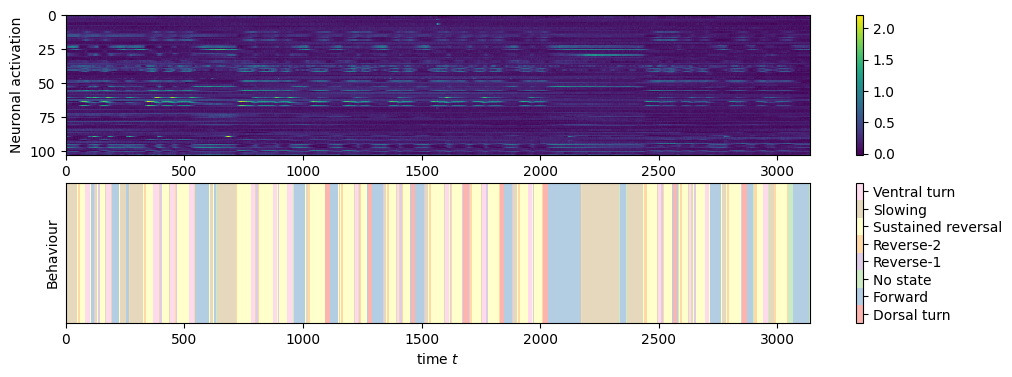

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [4]:
worm_num = 0
algorithm = 'BunDLe-Net'
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = '../datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour

plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names)

## Preprocess data and embed with BunDLe-Net

In [5]:
# Prepare data for BunDLe Net
x_, b_ = prep_data(x, b, win=15)

# Deploy BunDLe Net
model = BunDLeNet(latent_dim=3, num_behaviour=len(data.behaviour_names), input_shape=x_.shape)
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='discrete',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=1000
)

Loss [Markov, Behaviour, Total]: [0.0075 0.0041 0.0116]: 100%|██████████| 1000/1000 [09:47<00:00,  1.70it/s]


## Training loss versus epochs

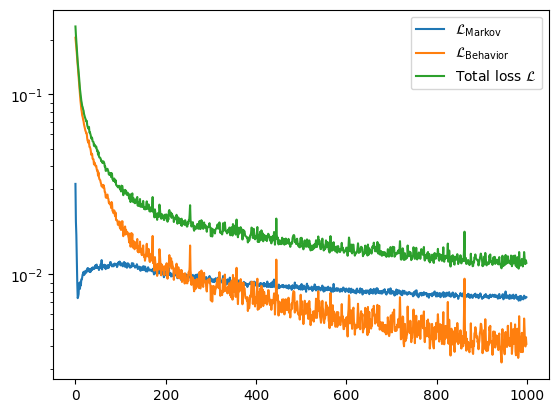

In [6]:
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total loss $\mathcal{L}$"
]):
    plt.semilogy(loss_array[:, i], label=label)
plt.legend()
plt.show()

## Projecting into latent space

In [7]:
y0_ = model_inference(x_, model)

## Visualising embedding

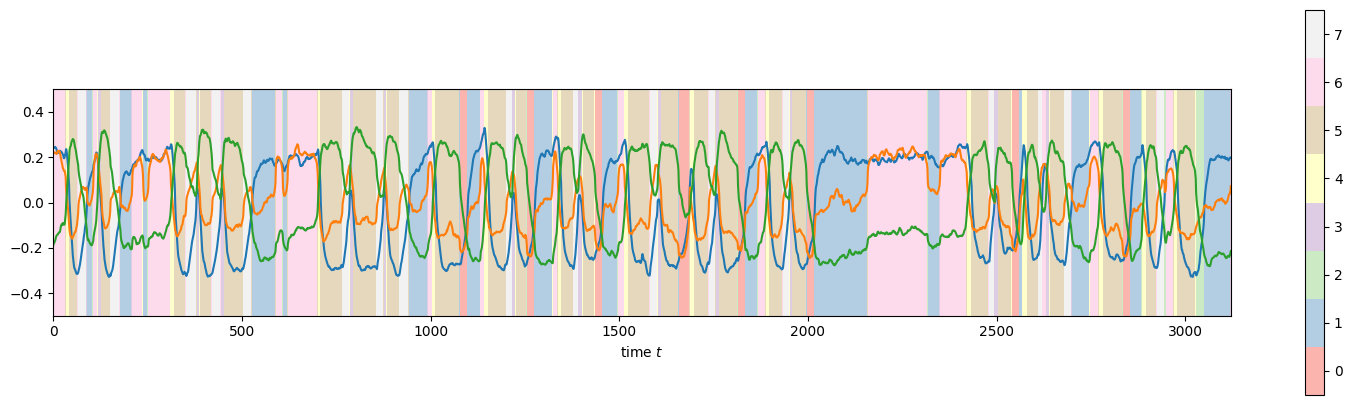

In [8]:
# Plotting latent space dynamics
vis = LatentSpaceVisualiser(y0_, b_, data.behaviour_names)
vis.plot_latent_timeseries()

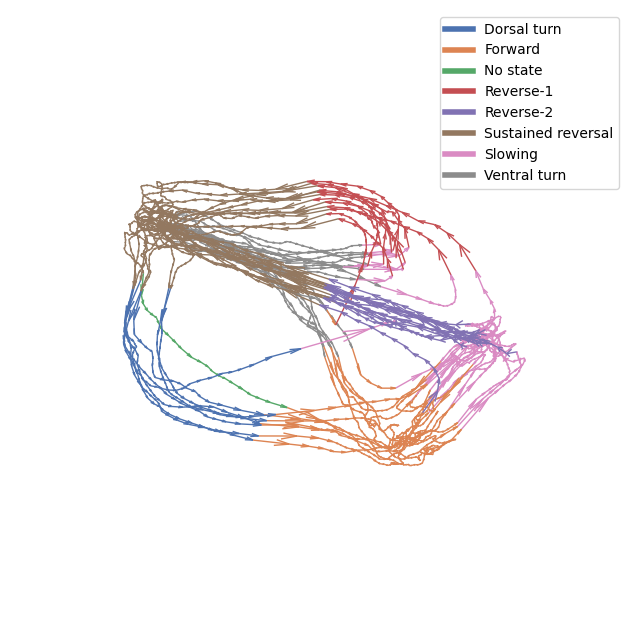

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [9]:
%matplotlib inline
vis.plot_phase_space()

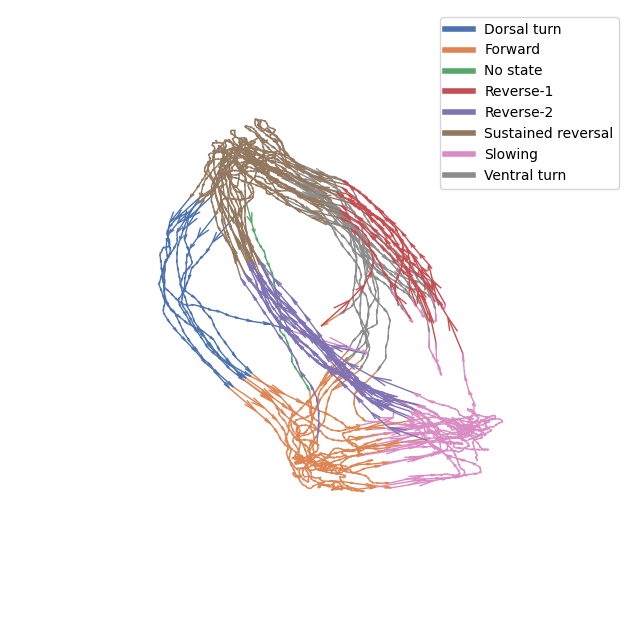

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [10]:
### Run to produce rotating 3-D plot
%matplotlib inline
vis.rotating_plot(filename='figures/rotation_' + algorithm + '_worm_' + str(worm_num) + '.gif')

### Recurrence plot analysis of BunDLeNet's embedding

<Figure size 640x480 with 0 Axes>

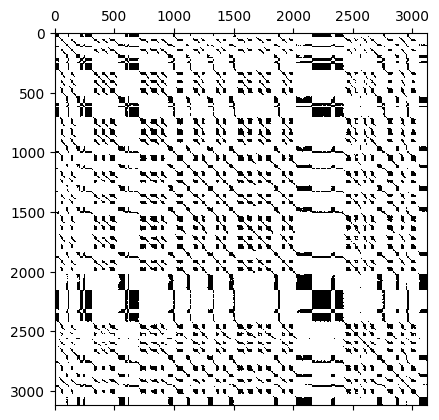

In [11]:
%matplotlib inline
pd_y = np.linalg.norm(y0_[:, np.newaxis] - y0_, axis=-1) < 0.8
plt.figure()
plt.matshow(pd_y, cmap='Greys')
plt.show()